<a href="https://colab.research.google.com/github/mke27/ECON3916-Statistical-Machine-Learning/blob/main/Class%208/Lab_8_The_Architecture_of_Evidence_%26_The_Digital_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# 1. Load Data (Lalonde Experimental Subset)
# Ensure 'lalonde.csv' is uploaded to your Colab environment
df = pd.read_csv('lalonde.csv')

# 2. Split Groups
treated = df[df["treat"] == 1]
control = df[df["treat"] == 0]


# Inspect the raw means (The "Economic Reality")
print(f"Mean Treated (re78): ${treated['re78'].mean():,.2f}")
print(f"Mean Control (re78): ${control['re78'].mean():,.2f}")

Mean Treated (re78): $6,349.14
Mean Control (re78): $6,984.17


Step 3: The Parametric T-Test (Signal-to-Noise)


In [10]:
# 3. Calculate Signal (Difference in Means)
signal = treated["re78"].mean() - control["re78"].mean()

print(f"Treatment Effect (Signal): ${signal:,.2f}")

# 4. Calculate Noise (T-Test)
# We use equal_var=False (Welch's T-Test) to account for unequal variances
from scipy import stats

t_stat, p_val = stats.ttest_ind(
    treated["re78"],
    control["re78"],
    equal_var=False  # Welch's t-test
)
print(f"T-Statistic (Signal/Noise): {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

# Decision Rule (Alpha = 0.05)
if p_val < 0.05:
    print("Reject Null: The training has a statistically significant effect.")
else:
    print("Fail to Reject Null: Result could be due to chance.")

Treatment Effect (Signal): $-635.03
T-Statistic (Signal/Noise): -0.9377
P-Value: 0.3491
Fail to Reject Null: Result could be due to chance.


Step 4: The Permutation Test (Non-Parametric)


In [13]:
# Define the test statistic function
def difference_in_means(x, y):
    return x.mean() - y.mean()


# Run Permutation Test (10,000 Resamples)
# This simulates "What if the treatment labels were meaningless?"

from scipy import stats

res = stats.permutation_test(
    (treated["re78"], control["re78"]),
    difference_in_means,
    permutation_type='independent',
    n_resamples=10000,
    alternative='two-sided'
)

print(f"Permutation P-Value: {res.pvalue:.4f}")
print("Compare this to your T-test P-value. Are they consistent?")

Permutation P-Value: 0.3522
Compare this to your T-test P-value. Are they consistent?


Step 5: Visualizing the Counterfactual


/tmp/ipython-input-1368903752.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(treated, fill=True, label='Treated (Training)', color='blue', alpha=0.3)
/tmp/ipython-input-1368903752.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(control, fill=True, label='Control (No Training)', color='red', alpha=0.3)


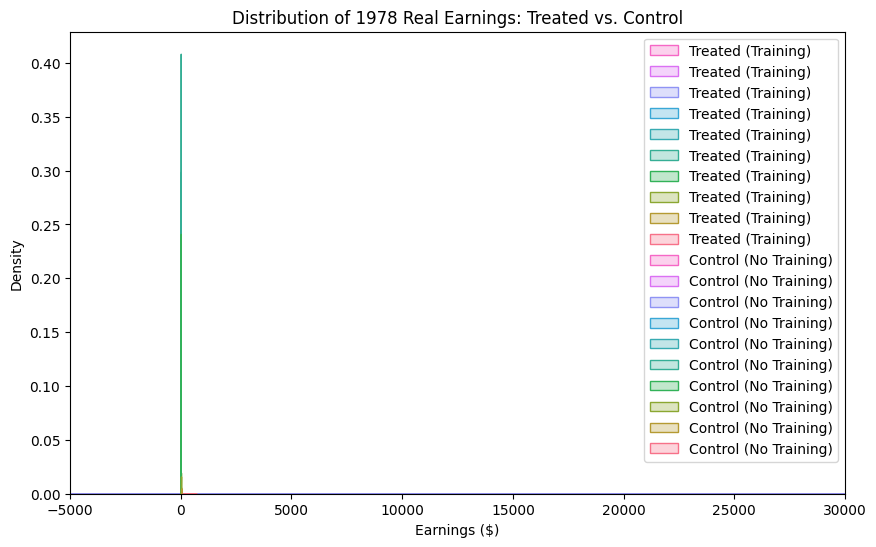

In [14]:
plt.figure(figsize=(10, 6))

# Plot KDE (Kernel Density Estimate) for both groups
sns.kdeplot(treated, fill=True, label='Treated (Training)', color='blue', alpha=0.3)
sns.kdeplot(control, fill=True, label='Control (No Training)', color='red', alpha=0.3)

plt.title('Distribution of 1978 Real Earnings: Treated vs. Control')
plt.xlabel('Earnings ($)')
plt.xlim(-5000, 30000) # Limit x-axis to focus on the core distribution
plt.legend()
plt.show()